In [7]:
import os 
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage
from IPython.display import Image, display

load_dotenv()
llm_openai = ChatOpenAI(model="gpt-4.1-mini", temperature=0)

In [3]:
# Task 1 - Graph Schema
class graph_schema(TypedDict):
  message_manual : List

In [11]:
# Task 2 - Creation of Nodes

# Node 1 
def create_post(state : graph_schema) -> graph_schema :
  message_manual = state['message_manual']

  response = llm_openai.invoke(message_manual).content
  response_ai = AIMessage(content=response)

  state['message_manual'] = message_manual + [response_ai]
  return state

# Node 2 
def currated_post(state : graph_schema) -> graph_schema : 
  message_manual = state['message_manual']

  response = llm_openai.invoke(message_manual).content
  response_ai = AIMessage(content=response)

  state['message_manual'] = message_manual + [response_ai]
  return state

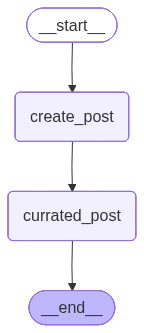

In [13]:
# Task 3 - Graph Creataion 
graph = StateGraph(graph_schema)

graph.add_node("create_post" , create_post)
graph.add_node("currated_post", currated_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "currated_post")
graph.add_edge("currated_post", END)

# Task 4 - Compile Graph
messages_graph = graph.compile()

Image(messages_graph.get_graph().draw_mermaid_png())

In [15]:
# Task 5 - Invoking the graph 
messages_graph.invoke(
  {"message_manual": [HumanMessage(content="The importance of formula one in automotive world")]}
)

{'message_manual': [HumanMessage(content='The importance of formula one in automotive world', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Formula One (F1) holds a significant place in the automotive world for several reasons, ranging from technological innovation to marketing and cultural impact. Here are some key points highlighting its importance:\n\n1. **Technological Innovation and Development**  \n   Formula One is often considered the pinnacle of automotive engineering. The intense competition and high-performance demands push teams to develop cutting-edge technologies in aerodynamics, materials science, engine efficiency, hybrid powertrains, and safety systems. Many innovations pioneered in F1 eventually trickle down to consumer vehicles, improving performance, fuel efficiency, and safety. Examples include advancements in carbon fiber construction, turbocharging, energy recovery systems (ERS), and braking technologies.\n\n2. **Safety Improvements**  \n   F1